In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

DATA_PATH = Path("../../dataset_final/dataset_distritos_long.csv")
KEY_COLS = ["municipio", "id_distrito", "year", "quarter", "period_ord"]


# EDA

In [2]:
df = pd.read_csv(DATA_PATH, encoding="utf-8")
print("Shape:", df.shape)
df.head()


Shape: (3640, 126)


,id_dera,cod_mun,nombre,provincia,id_distrito,nombre_distrito,__did__,district_area_m2,district_area_km2,n_poi_total,...,water_to_building,activity_per_building_m2,noise_proxy_len,poi_per_km2,buildings_per_km2,roads_km_per_km2,year,quarter,price_m2,municipio
0,1.131640e+13,29007,Alhaurín de la Torre,Málaga,1,Alquería - Torrealquería,1,1.399005e+07,13.990049,25,...,202.371654,0.0,0.0,1.786984,0.357397,0.0,2015,Q1,1768.00,alhaurin_de_la_torre
1,1.131640e+13,29007,Alhaurín de la Torre,Málaga,1,Alquería - Torrealquería,1,1.399005e+07,13.990049,27,...,202.371654,0.0,0.0,1.929943,0.357397,0.0,2015,Q2,1600.00,alhaurin_de_la_torre
2,1.131640e+13,29007,Alhaurín de la Torre,Málaga,1,Alquería - Torrealquería,1,1.399005e+07,13.990049,27,...,202.371654,0.0,0.0,1.929943,0.357397,0.0,2015,Q3,1596.33,alhaurin_de_la_torre
3,1.131640e+13,29007,Alhaurín de la Torre,Málaga,1,Alquería - Torrealquería,1,1.399005e+07,13.990049,27,...,202.371654,0.0,0.0,1.929943,0.357397,0.0,2015,Q4,1588.00,alhaurin_de_la_torre
4,1.131640e+13,29007,Alhaurín de la Torre,Málaga,1,Alquería - Torrealquería,1,1.399005e+07,13.990049,26,...,202.371654,0.0,0.0,1.858464,0.357397,0.0,2016,Q1,1499.33,alhaurin_de_la_torre


In [3]:
df = df.copy()

df["quarter"] = df["quarter"].astype(str).str.upper().str.replace(" ", "")
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["id_distrito"] = pd.to_numeric(df["id_distrito"], errors="coerce").astype("Int64")

q_map = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
df["q_num"] = df["quarter"].map(q_map).astype("Int64")

df["period"] = df["year"].astype(str) + "_Q" + df["q_num"].astype(str)
df["period_ord"] = df["year"].astype(float) * 10 + df["q_num"].astype(float)

df[["year","quarter","q_num","period","period_ord"]].head(10)


,year,quarter,q_num,period,period_ord
0,2015,Q1,1,2015_Q1,20151.0
1,2015,Q2,2,2015_Q2,20152.0
2,2015,Q3,3,2015_Q3,20153.0
3,2015,Q4,4,2015_Q4,20154.0
4,2016,Q1,1,2016_Q1,20161.0
5,2016,Q2,2,2016_Q2,20162.0
6,2016,Q3,3,2016_Q3,20163.0
7,2016,Q4,4,2016_Q4,20164.0
8,2017,Q1,1,2017_Q1,20171.0
9,2017,Q2,2,2017_Q2,20172.0


## Análisis de ceros

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df_ = df.copy()

num_cols = df_.select_dtypes(include=[np.number]).columns.tolist()
exclude = {"year", "period_ord", "q_num", "cod_mun", "id_distrito"}
num_cols = [c for c in num_cols if c not in exclude]

def zero_share(s):
    return (s == 0).mean()

def pos_share(s):
    return (s > 0).mean()

def skew_pos(s):
    sp = s[s > 0]
    return np.nan if len(sp) < 3 else sp.skew()

diag = pd.DataFrame({
    "n": df_[num_cols].count(),
    "pct_null": df_[num_cols].isna().mean()*100,
    "pct_zero": df_[num_cols].apply(zero_share)*100,
    "pct_pos": df_[num_cols].apply(pos_share)*100,
    "skew_all": df_[num_cols].skew(numeric_only=True),
    "skew_pos_only": df_[num_cols].apply(skew_pos),
}).sort_values(["pct_zero","skew_all"], ascending=[False, False])

diag.head(20)


,n,pct_null,pct_zero,pct_pos,skew_all,skew_pos_only
area_act_craft_m2,3640,0.0,97.280220,2.719780,57.225620,9.758619
pct_act_craft,3640,0.0,97.280220,2.719780,17.102413,6.875634
pct_act_finance,3640,0.0,97.115385,2.884615,8.625338,1.487388
area_act_finance_m2,3640,0.0,97.115385,2.884615,6.948112,0.029951
len_aerialway,3640,0.0,96.703297,3.296703,5.396653,-0.736568
n_poi_pt_entrance,3640,0.0,95.659341,4.340659,6.338751,0.560965
pct_act_tourism_other,3640,0.0,88.901099,11.098901,9.381103,2.868215
area_act_tourism_other_m2,3640,0.0,88.901099,11.098901,7.161786,1.847122
n_poi_enforcement,3640,0.0,85.824176,14.175824,3.800585,1.796935
area_act_office_m2,3640,0.0,85.137363,14.862637,8.865026,3.088479


<Figure size 600x800 with 0 Axes>

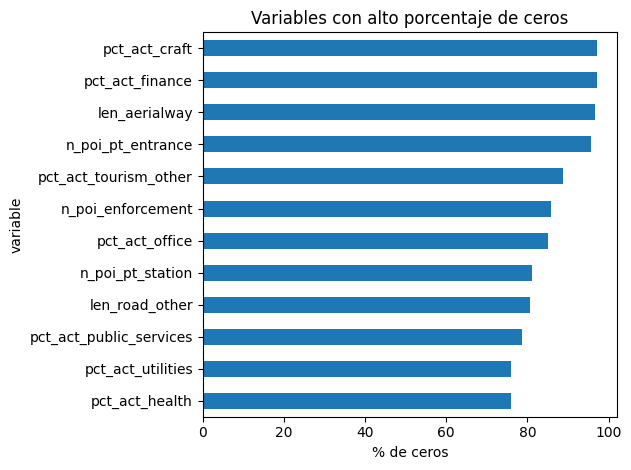

In [5]:
import re
import matplotlib.pyplot as plt

# % de ceros
zero_pct = (df == 0).mean() * 100
zero_pct = zero_pct.sort_values(ascending=False)


def base_name(col):
    col = re.sub(r'^pct_', '', col)
    col = re.sub(r'^area_', '', col)
    col = re.sub(r'_m2$', '', col)
    return col

zp = zero_pct.reset_index()
zp.columns = ["variable", "pct_zero"]
zp["base"] = zp["variable"].apply(base_name)


def priority(col):
    if col.startswith("pct_"):
        return 0
    if col.startswith("area_"):
        return 1
    return 2

zp["priority"] = zp["variable"].apply(priority)

zp_unique = (
    zp.sort_values(["base", "priority"])
      .drop_duplicates(subset="base")
      .sort_values("pct_zero", ascending=False)
)

# Plot
plt.figure(figsize=(6, 8))
zp_unique.head(12).plot(
    kind="barh",
    x="variable",
    y="pct_zero",
    legend=False
)
plt.xlabel("% de ceros")
plt.title("Variables con alto porcentaje de ceros")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Asimetría de variables

In [6]:
skew_tbl = []
for c in num_cols:
    s = df[c]
    skew_tbl.append({
        "feature": c,
        "non_null": int(s.notna().sum()),
        "null_pct": float(s.isna().mean() * 100),
        "zero_pct": float((s.fillna(0) == 0).mean() * 100),
        "mean": float(s.mean(skipna=True)) if s.notna().any() else np.nan,
        "p50": float(s.median(skipna=True)) if s.notna().any() else np.nan,
        "p95": float(s.quantile(0.95)) if s.notna().any() else np.nan,
        "skew": float(s.skew(skipna=True)) if s.notna().any() else np.nan,
    })

skew_df = pd.DataFrame(skew_tbl).sort_values("skew", ascending=False)


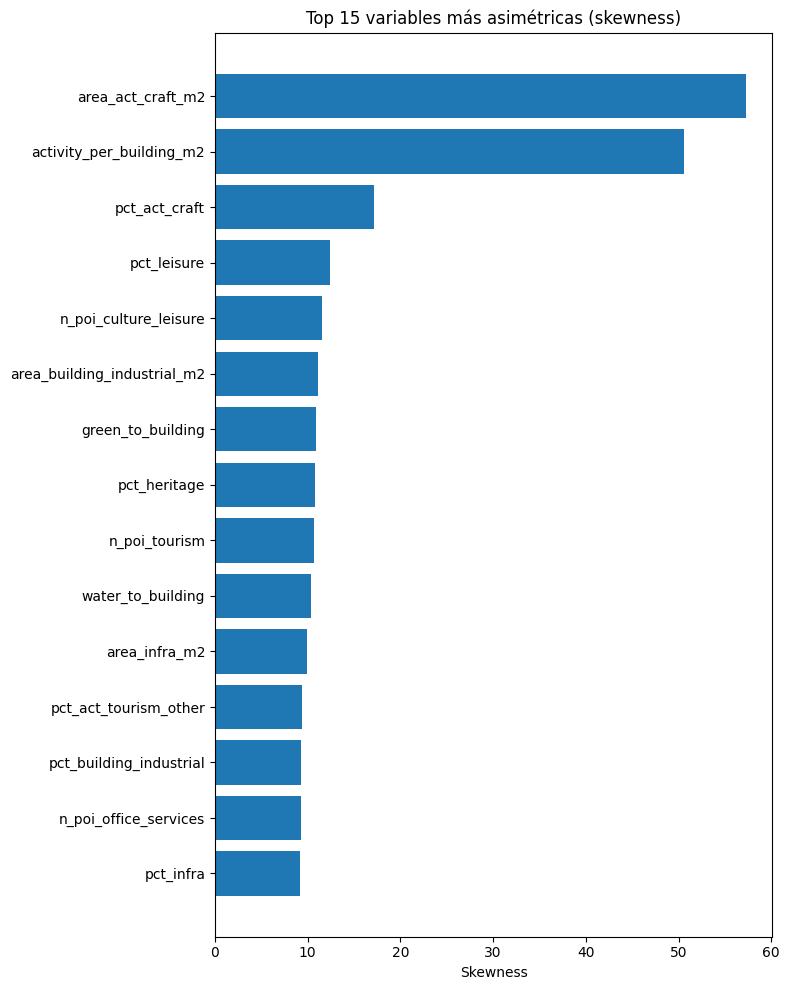

In [7]:
topk = 15
plot_df = skew_df.dropna(subset=["skew"]).head(topk).iloc[::-1]

plt.figure(figsize=(8, 10))
plt.barh(plot_df["feature"], plot_df["skew"])
plt.title(f"Top {topk} variables más asimétricas (skewness)")
plt.xlabel("Skewness")
plt.tight_layout()
plt.show()


In [8]:
def plot_original_vs_logpos(series, name=None, p=0.99, bins=40):
    s = series.dropna()
    name = name or series.name

    # recorte para visualizar cola
    cap = s.quantile(p)
    s_clip = s.clip(upper=cap)

    pos = s[s > 0]
    pos_clip = pos.clip(upper=pos.quantile(p)) if len(pos) else pos

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].hist(s_clip, bins=bins)
    ax[0].set_title(f"{name} (original, recorte p{int(p*100)})")
    ax[0].set_xlabel(name)
    ax[0].set_ylabel("count")

    if len(pos_clip) > 0:
        ax[1].hist(np.log1p(pos_clip), bins=bins)
        ax[1].set_title(f"log1p({name}) (solo >0, recorte p{int(p*100)})")
        ax[1].set_xlabel(f"log1p({name}) (solo >0)")
        ax[1].set_ylabel("count")
    else:
        ax[1].text(0.5, 0.5, "Sin positivos", ha="center", va="center")
        ax[1].set_axis_off()

    plt.tight_layout()
    plt.show()


cands = skew_df[(skew_df["zero_pct"] < 99) & (skew_df["non_null"] > 100)].head(6)["feature"].tolist()
cands


['area_act_craft_m2',
 'activity_per_building_m2',
 'pct_act_craft',
 'pct_leisure',
 'n_poi_culture_leisure',
 'area_building_industrial_m2']

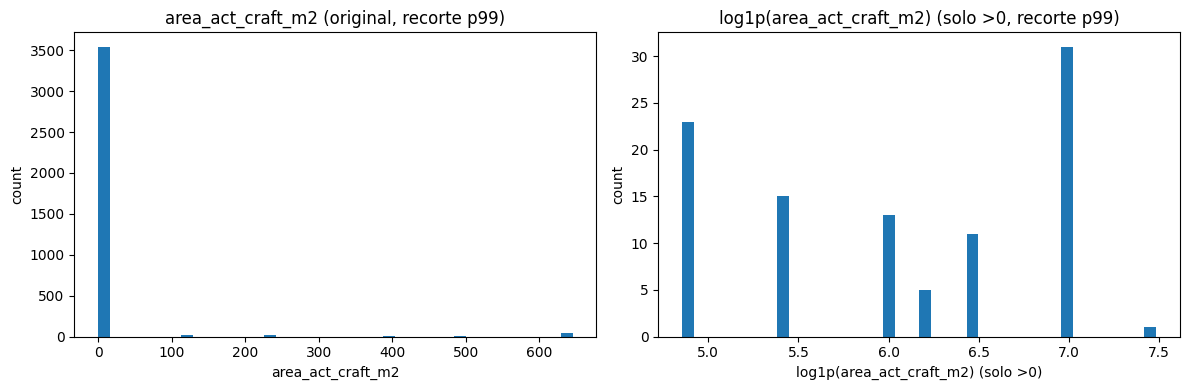

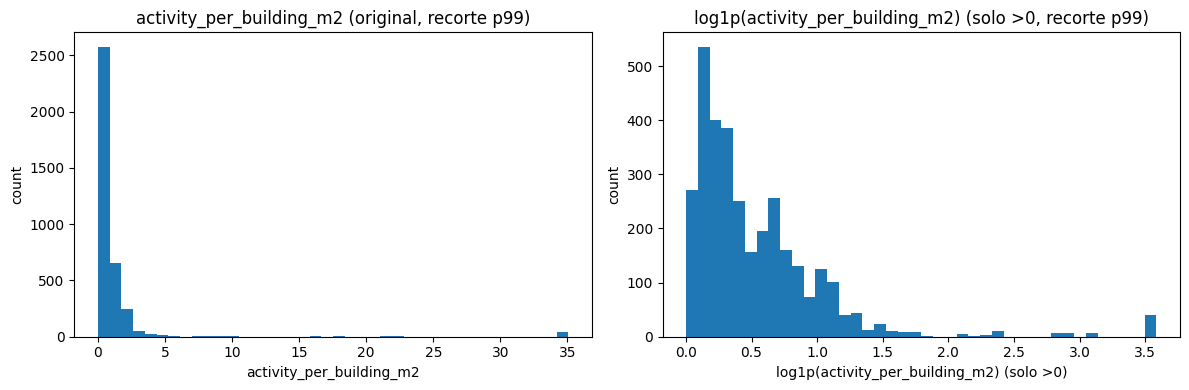

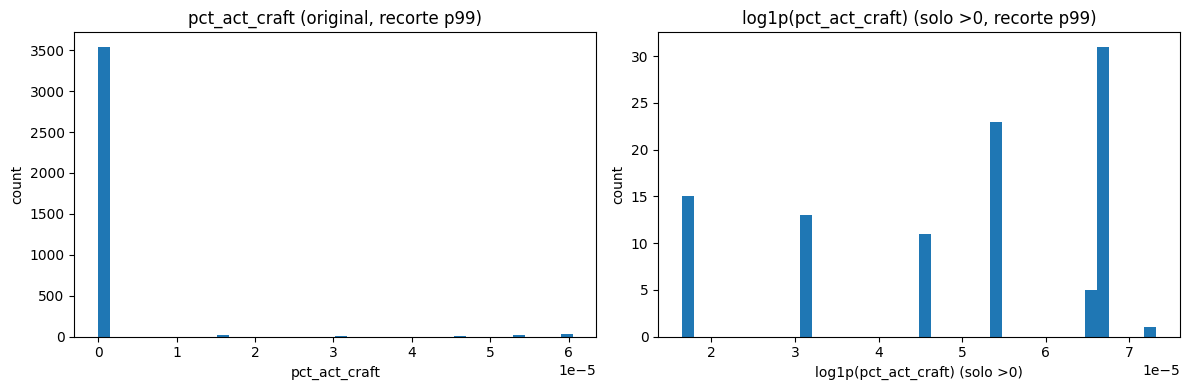

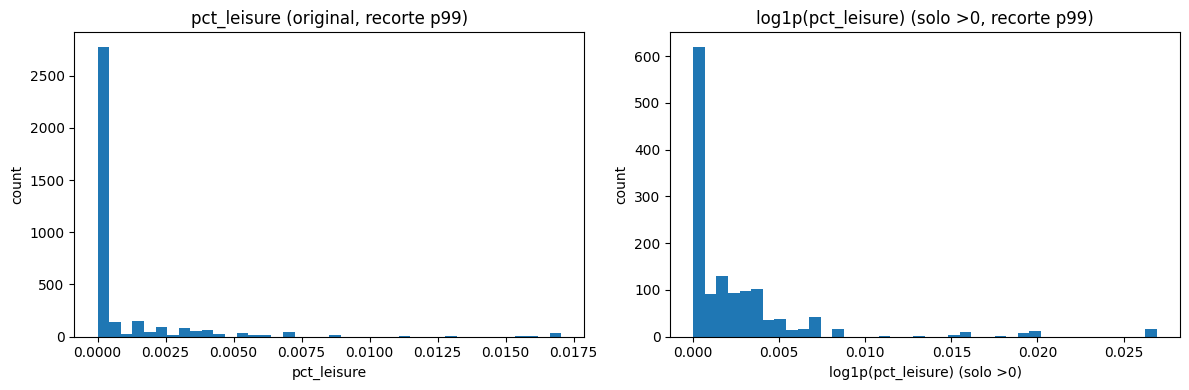

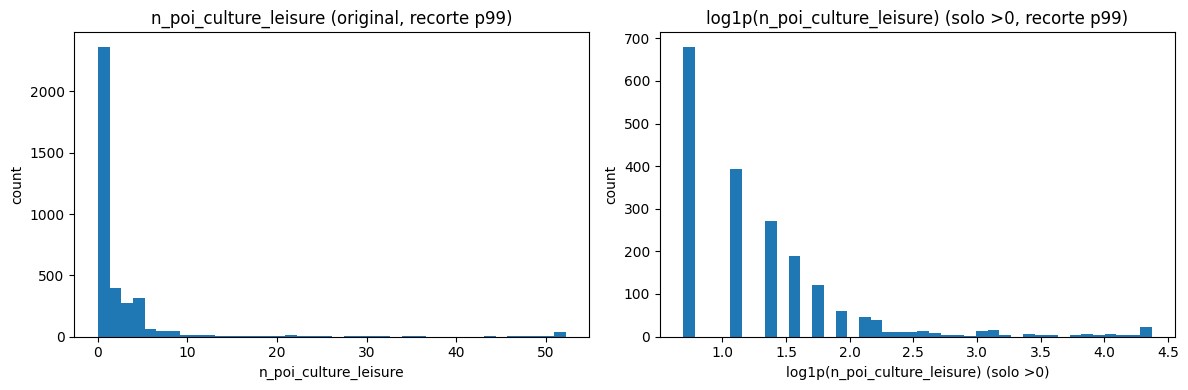

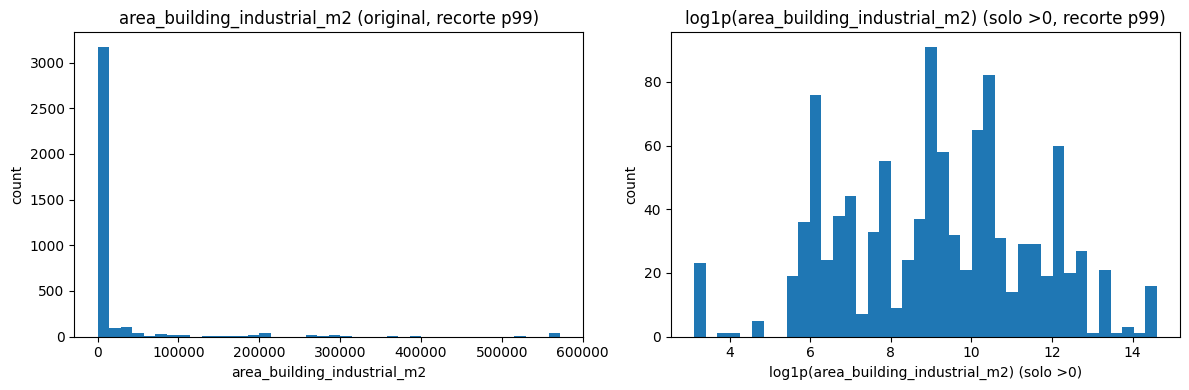

In [9]:
for c in cands:
    plot_original_vs_logpos(df[c], name=c)

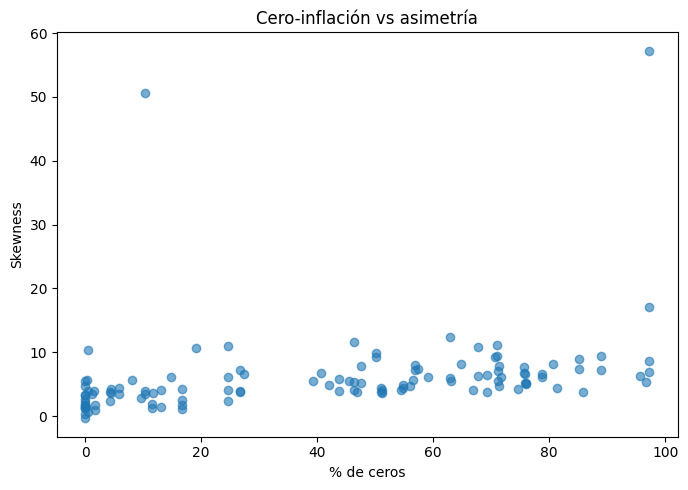

,feature,zero_pct,skew,null_pct,p95
76,area_act_craft_m2,97.280220,57.225620,0.0,0.0
77,pct_act_craft,97.280220,17.102413,0.0,0.0
57,pct_act_finance,97.115385,8.625338,0.0,0.0
56,area_act_finance_m2,97.115385,6.948112,0.0,0.0
21,n_poi_pt_entrance,95.659341,6.338751,0.0,0.0
107,len_aerialway,96.703297,5.396653,0.0,0.0


In [10]:
tmp = skew_df.dropna(subset=["skew"]).copy()

plt.figure(figsize=(7,5))
plt.scatter(tmp["zero_pct"], tmp["skew"], alpha=0.6)
plt.xlabel("% de ceros")
plt.ylabel("Skewness")
plt.title("Cero-inflación vs asimetría")
plt.tight_layout()
plt.show()

out = tmp[(tmp["zero_pct"] > 90) & (tmp["skew"] > 5)].head(15)
out[["feature","zero_pct","skew","null_pct","p95"]]

## Análisis de valores nulos

### Nulos en Variables

In [11]:
nulls = pd.DataFrame({
    "null_count": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str)
}).sort_values("null_pct", ascending=False)

nulls.head(30)


,null_count,null_pct,dtype
price_m2,473,12.99,float64
id_dera,0,0.00,float64
cod_mun,0,0.00,int64
provincia,0,0.00,object
nombre,0,0.00,object
nombre_distrito,0,0.00,object
__did__,0,0.00,int64
district_area_m2,0,0.00,float64
id_distrito,0,0.00,Int64
n_poi_total,0,0.00,int64


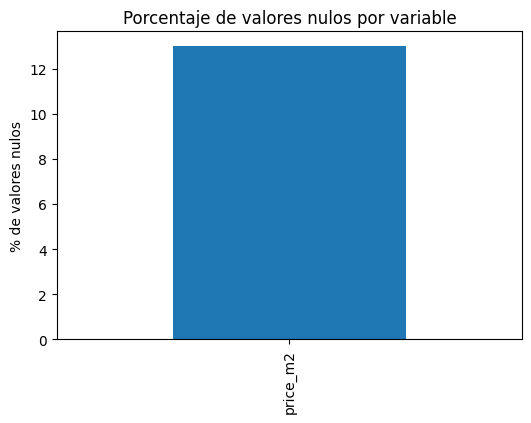

In [12]:
nulls = df.isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(6,4))
nulls[nulls > 0].plot(kind='bar')
plt.ylabel('% de valores nulos')
plt.title('Porcentaje de valores nulos por variable')
plt.show()


### Nulos por municipio

In [13]:
null_by_mun = df.groupby("municipio").apply(lambda x: x.isna().mean().mean() * 100).sort_values(ascending=False)
null_by_mun.head(15)


C:\Users\sergi\AppData\Local\Temp\ipykernel_36756\1787315092.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_by_mun = df.groupby("municipio").apply(lambda x: x.isna().mean().mean() * 100).sort_values(ascending=False)


municipio
rincon_de_la_victoria    0.243325
benahavis                0.204565
mijas                    0.193798
alhaurin_de_la_torre     0.088286
fuengirola               0.086133
estepona                 0.077519
malaga                   0.056378
benalmadena              0.000000
marbella                 0.000000
torremolinos             0.000000
dtype: float64

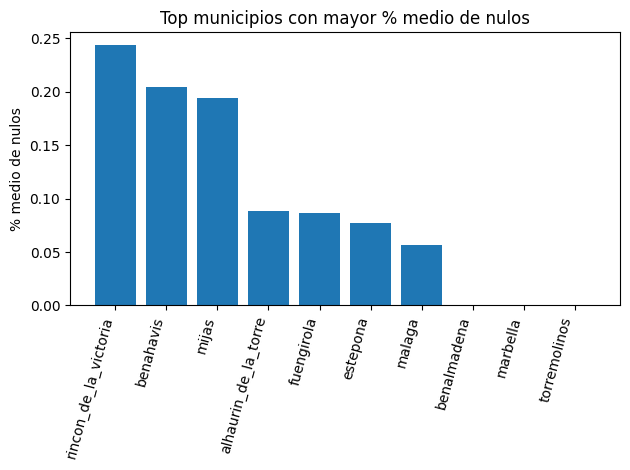

In [14]:
top_mun = null_by_mun.head(15)

plt.figure()
plt.bar(top_mun.index.astype(str), top_mun.values)
plt.title("Top municipios con mayor % medio de nulos")
plt.xticks(rotation=75, ha="right")
plt.ylabel("% medio de nulos")
plt.tight_layout()
plt.show()


### Nulos por año

In [15]:
null_by_period = (
    df.groupby(["year","quarter"])
      .apply(lambda x: x.isna().mean().mean() * 100)
      .reset_index(name="avg_null_pct")
      .sort_values(["year","quarter"])
)


C:\Users\sergi\AppData\Local\Temp\ipykernel_36756\2457893138.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean().mean() * 100)


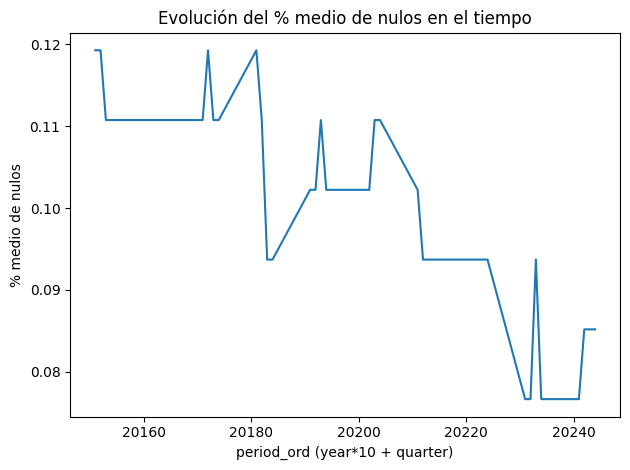

In [16]:

tmp = null_by_period.copy()
tmp["q_num"] = tmp["quarter"].map(q_map)
tmp["period_ord"] = tmp["year"].astype(float) * 10 + tmp["q_num"].astype(float)
tmp = tmp.sort_values("period_ord")

plt.figure()
plt.plot(tmp["period_ord"], tmp["avg_null_pct"])
plt.title("Evolución del % medio de nulos en el tiempo")
plt.xlabel("period_ord (year*10 + quarter)")
plt.ylabel("% medio de nulos")
plt.tight_layout()
plt.show()


## Investigar Price

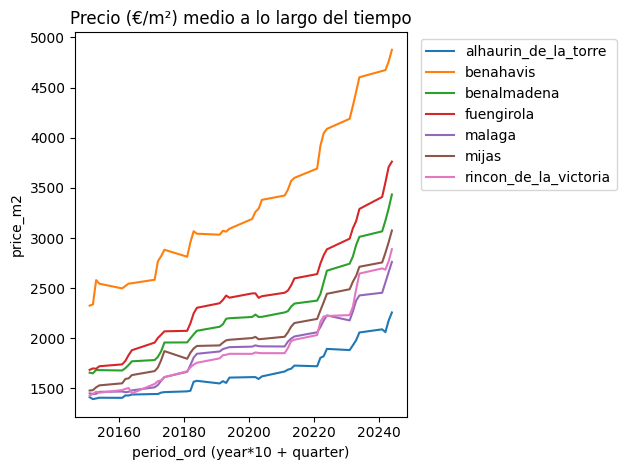

In [17]:
feature = "price_m2"
if feature not in df.columns:
    print("No existe price_m2 en el dataset.")
else:
    # 7 municipios para que no sea ilegible
    top_muns = df["municipio"].value_counts().head(7).index.tolist()

    d = df[df["municipio"].isin(top_muns)].dropna(subset=["period_ord", feature]).copy()
    g = d.groupby(["municipio","period_ord"])[feature].mean().reset_index()

    plt.figure()
    for mun, sub in g.groupby("municipio"):
        sub = sub.sort_values("period_ord")
        plt.plot(sub["period_ord"], sub[feature], label=mun)

    plt.title("Precio (€/m²) medio a lo largo del tiempo")
    plt.xlabel("period_ord (year*10 + quarter)")
    plt.ylabel("price_m2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [18]:
MUN = "alhaurin_de_la_torre"
DID = 1
FEATURE = "price_m2"

d = df[(df["municipio"] == MUN) & (df["id_distrito"] == DID)].dropna(subset=["period_ord", FEATURE]).copy()
d = d.sort_values("period_ord")

print("Filas:", len(d))
d[["municipio","id_distrito","year","quarter",FEATURE]].head(10)


Filas: 28


,municipio,id_distrito,year,quarter,price_m2
0,alhaurin_de_la_torre,1,2015,Q1,1768.00
1,alhaurin_de_la_torre,1,2015,Q2,1600.00
2,alhaurin_de_la_torre,1,2015,Q3,1596.33
3,alhaurin_de_la_torre,1,2015,Q4,1588.00
4,alhaurin_de_la_torre,1,2016,Q1,1499.33
5,alhaurin_de_la_torre,1,2016,Q2,1496.67
6,alhaurin_de_la_torre,1,2016,Q3,1504.00
7,alhaurin_de_la_torre,1,2016,Q4,1548.33
8,alhaurin_de_la_torre,1,2017,Q1,1556.00
10,alhaurin_de_la_torre,1,2017,Q3,1623.50


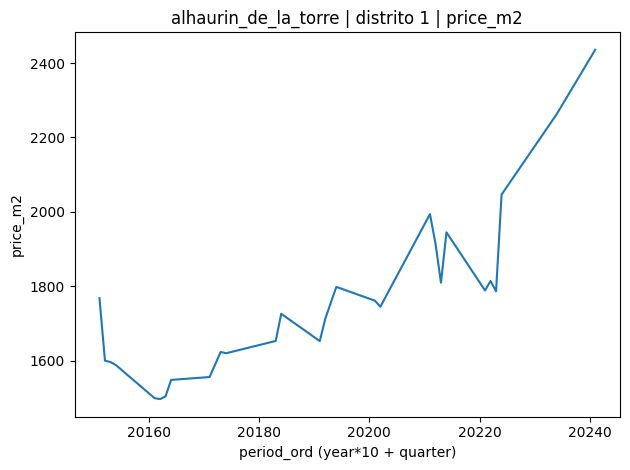

In [19]:
if d.empty:
    print("No hay datos para ese distrito/feature.")
else:
    plt.figure()
    plt.plot(d["period_ord"], d[FEATURE])
    plt.title(f"{MUN} | distrito {DID} | {FEATURE}")
    plt.xlabel("period_ord (year*10 + quarter)")
    plt.ylabel(FEATURE)
    plt.tight_layout()
    plt.show()


# Feature engineering

## Contexto municipal

In [20]:
def add_municipal_context(df, price_col="price_m2"):
    d = df.copy()

    # Precio medio del municipio en ese año
    d["mun_price_mean"] = (
        d.groupby(["municipio","year"])[price_col]
         .transform("mean")
    )

    # Desviación del distrito respecto al municipio
    d["price_vs_mun"] = d[price_col] - d["mun_price_mean"]

    return d


## Añadimos el target price_next

In [21]:
def add_delta_target(
    df,
    price_col="price_m2",
    group_cols=("municipio","id_distrito"),
    horizon=1
):
    d = df.sort_values(list(group_cols) + ["period_ord"]).copy()

    d["price_next"] = (
        d.groupby(list(group_cols))[price_col]
        .shift(-horizon)
    )

    d["target_delta"] = d["price_next"] - d[price_col]

    return d


## Trend features

In [22]:
def add_trend_features(df, group_cols=("municipio","id_distrito")):
    """
    Añade features de tendencia basadas en lags ya existentes:
      - price_trend_4 = price_m2 - price_lag_4
      - price_vs_mun_trend_4 = price_vs_mun - shift_4(price_vs_mun)
    """
    d = df.sort_values(list(group_cols) + ["period_ord"]).copy()

    # anual (4 trimestres)
    if "price_lag_4" in d.columns:
        d["price_trend_4"] = d["price_m2"] - d["price_lag_4"]
    else:
        d["price_trend_4"] = np.nan

    # Tendencia relativa (posición vs municipio)
    d["price_vs_mun_lag_4"] = d.groupby(list(group_cols))["price_vs_mun"].shift(4)
    d["price_vs_mun_trend_4"] = d["price_vs_mun"] - d["price_vs_mun_lag_4"]

    return d


## Lags simples

* lag=1 → trimestre anterior
* lag=4 → mismo trimestre año anterior

In [23]:
def add_price_lags(
    df,
    price_col="price_m2",
    group_cols=("municipio","id_distrito"),
    lags=(1,4)
):
    d = df.sort_values(list(group_cols) + ["period_ord"]).copy()

    for lag in lags:
        d[f"price_lag_{lag}"] = (
            d.groupby(list(group_cols))[price_col].shift(lag)
        )

    return d


In [24]:
lag_cols = [c for c in df.columns if c.startswith("price_lag_")]
trend_cols = [c for c in df.columns if "trend" in c or "roll" in c]
time_cols = ["municipio", "period"] 

cols_to_fix = lag_cols + trend_cols

for c in cols_to_fix:
    df[f"miss_{c}"] = df[c].isna().astype(int)

# Imputación: media municipal por periodo
grp = df.groupby(["municipio", "period"])
for c in cols_to_fix:
    df[c] = df[c].fillna(grp[c].transform("mean"))
    df[c] = df[c].fillna(df[c].mean())


## Aparición de actividad (evento 0 → >0)

In [25]:
def add_activity_appearance(
    df,
    area_cols
):
    """
    Crea variables binarias:
      appear_<var> = 1 si pasa de 0 a >0
    """
    d = df.sort_values(["municipio","id_distrito","period_ord"]).copy()

    for c in area_cols:
        prev = d.groupby(["municipio","id_distrito"])[c].shift(1)
        d[f"appear_{c}"] = ((prev == 0) & (d[c] > 0)).astype(int)

    return d


In [26]:
def fix_missing_lags_trends(
    df: pd.DataFrame,
    group_cols=("municipio", "period"),
    lag_prefix="price_lag_",
    trend_markers=("trend", "roll"),
    add_missing_flags=True,
    fill_strategy="mun_period_mean",
    make_defrag_copy=True
) -> pd.DataFrame:
    d = df.copy()

    lag_cols = [c for c in d.columns if c.startswith(lag_prefix)]
    trend_cols = [c for c in d.columns if any(m in c for m in trend_markers)]
    cols_to_fix = lag_cols + trend_cols

    if not cols_to_fix:
        return d

    # 1) Flags missing
    if add_missing_flags:
        miss_cols = {f"miss_{c}": d[c].isna().astype("int8") for c in cols_to_fix}
        d = pd.concat([d, pd.DataFrame(miss_cols, index=d.index)], axis=1)

    # 2) Imputación
    if fill_strategy == "mun_period_mean":
        grp = d.groupby(list(group_cols))
        for c in cols_to_fix:
            d[c] = d[c].fillna(grp[c].transform("mean"))
            d[c] = d[c].fillna(d[c].mean())
    elif fill_strategy == "mun_mean":
        grp = d.groupby(group_cols[0])
        for c in cols_to_fix:
            d[c] = d[c].fillna(grp[c].transform("mean"))
            d[c] = d[c].fillna(d[c].mean())
    elif fill_strategy == "global_mean":
        for c in cols_to_fix:
            d[c] = d[c].fillna(d[c].mean())
    else:
        raise ValueError("fill_strategy no reconocido")

    if make_defrag_copy:
        d = d.copy()

    return d


In [27]:
AREA_ACTIVITY_COLS_CORE = [
    "area_act_tourism_accommodation_m2",
    "area_act_tourism_attraction_m2",
    "area_act_tourism_other_m2",
    "area_act_office_m2",
    "area_act_culture_leisure_m2",
    "area_act_shop_m2",
]


Quitamos nulos en price

In [28]:
df = df.dropna(subset=["price_m2"]).copy()

## Aplicación del pipeline

In [29]:
df0 = df.copy()

# 1) Contexto municipal
df1 = add_municipal_context(df0)

# 2) Lags de precio
df2 = add_price_lags(df1, lags=(1, 4))
df3  = add_delta_target(df2, horizon=1) # opcional

# 3) Tendencias
df3c = add_trend_features(df3)

# 4) Fix missing  de lags/tendencias
df3e = fix_missing_lags_trends(df3c, group_cols=("municipio", "period"), add_missing_flags=False)

# 5) Aparición de actividad
df_final = add_activity_appearance(df3e, AREA_ACTIVITY_COLS_CORE)

In [30]:
df_final.to_csv("../../dataset_final/dataset_distritos_procesado.csv", index=False, encoding="utf-8")

# Checks

In [31]:
# Contar nulos por columna
nulos_por_columna = df_final.isnull().sum()

# Mostrar solo las columnas que tienen nulos
nulos_por_columna = nulos_por_columna[nulos_por_columna > 0]

print(nulos_por_columna)


price_next             83
target_delta           83
price_vs_mun_lag_4    332
dtype: int64


## Check contexto municipal

* price_vs_mun > 0 → distrito más caro que la media municipal
* price_vs_mun < 0 → distrito más barato que la media municipal

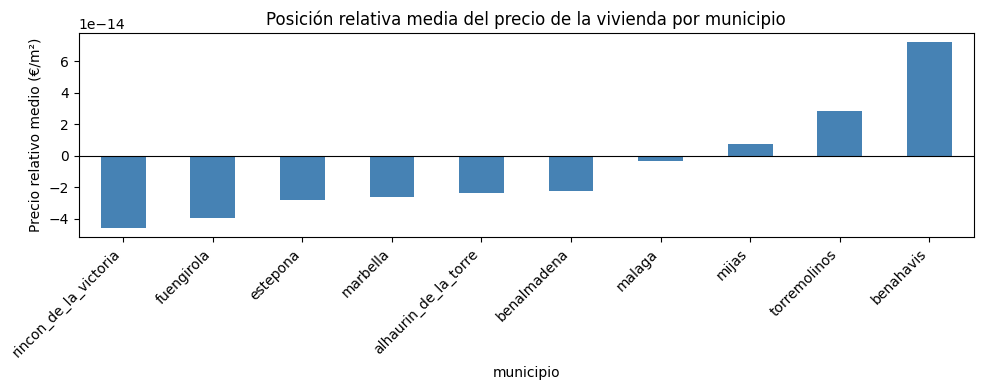

In [32]:
# Media del indicador relativo por municipio
mun_ctx = (
    df_final
    .groupby("municipio")["price_vs_mun"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,4))
mun_ctx.plot(kind="bar", color="steelblue")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Precio relativo medio (€/m²)")
plt.title("Posición relativa media del precio de la vivienda por municipio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [33]:
(df1.groupby(["municipio","year"])["price_vs_mun"].mean()
 .abs().sort_values(ascending=False).head(10))


municipio              year
marbella               2019    3.897834e-13
benahavis              2022    3.248195e-13
marbella               2021    3.248195e-13
                       2023    3.248195e-13
benahavis              2018    2.694799e-13
marbella               2017    2.598556e-13
estepona               2018    2.598556e-13
mijas                  2024    2.526374e-13
benalmadena            2023    2.526374e-13
rincon_de_la_victoria  2022    2.273737e-13
Name: price_vs_mun, dtype: float64

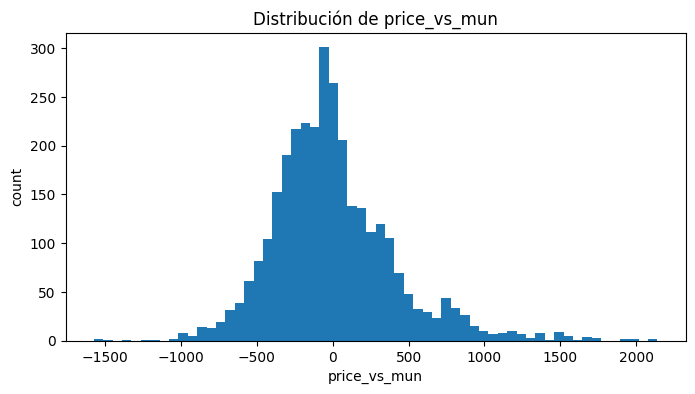

In [34]:
plt.figure(figsize=(8,4))
plt.hist(df1["price_vs_mun"].dropna(), bins=60)
plt.title("Distribución de price_vs_mun")
plt.xlabel("price_vs_mun"); plt.ylabel("count")
plt.show()


* Pico fuerte en 0
* Cola positiva y negativa
* Distribución aproximadamente simétrica
* La mayoría de distritos están cerca de la media


## Check lags

In [35]:
(df2.assign(isna_l1=df2["price_lag_1"].isna())
    .groupby(["municipio","id_distrito"])["isna_l1"].sum()
    .value_counts()
    .sort_index())


isna_l1
1    83
Name: count, dtype: int64

In [36]:
(df2.assign(isna_l4=df2["price_lag_4"].isna())
    .groupby(["municipio","id_distrito"])["isna_l4"].sum()
    .value_counts()
    .sort_index())


isna_l4
4    83
Name: count, dtype: int64

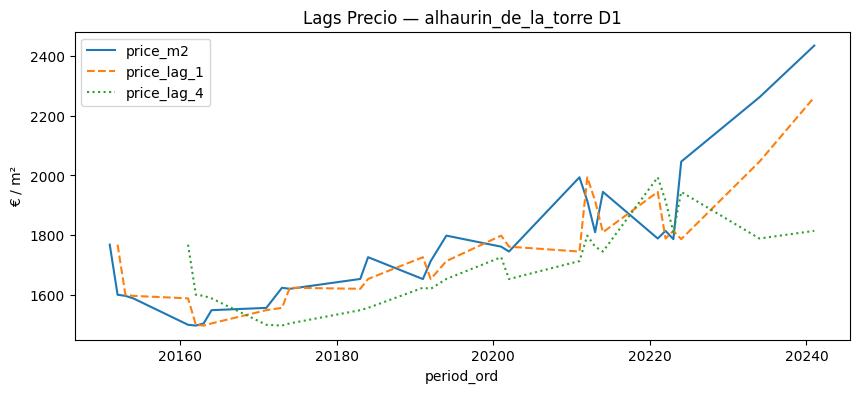

In [37]:
m = "alhaurin_de_la_torre"       
did = 1               

sub = (
    df2[(df2["municipio"] == m) & (df2["id_distrito"] == did)]
    .sort_values("period_ord")
)

plt.figure(figsize=(10,4))
plt.plot(sub["period_ord"], sub["price_m2"], label="price_m2")
plt.plot(sub["period_ord"], sub["price_lag_1"], label="price_lag_1", linestyle="--")
plt.plot(sub["period_ord"], sub["price_lag_4"], label="price_lag_4", linestyle=":")
plt.title(f"Lags Precio — {m} D{did}")
plt.xlabel("period_ord")
plt.ylabel("€ / m²")
plt.legend()
plt.show()
